# [6.1] SAE Variants

By the end of this notebook, you will have trained four sparse autoencoder variants on the same exact planted dictionary and shown why reconstruction alone is not enough to claim feature recovery.

```yaml
gt_tier: GT-1 real-model preflight with GT-0 exact planted controls
exercise_id: 6_1_sae_variants
expected_runtime: 60-90 minutes; solved CPU signature run takes about 4 seconds
requires_gpu: false for the lesson; the parent runner owns the optional Pythia CUDA path
```

## Core Question

Suppose eight sparse latent features are mixed into six activation dimensions. If ReLU-L1, TopK, gated, and JumpReLU SAEs see the same train split, which rule best recovers the planted dictionary, and do its learned features survive held-out and causal controls?

The answer cannot come from one loss value. You will keep five claims separate: reconstruction, sparsity, dictionary recovery, held-out prediction, and intervention.

## Learning Objectives

- Generate activations as `x = z @ D + noise` with the true sparse code `z` and dictionary `D` retained.
- Implement ReLU-L1, TopK, gated, and JumpReLU encoder mechanics.
- Put L1 pressure in the objective, implement the gated auxiliary loss, and give JumpReLU a threshold pseudo-gradient.
- Match learned decoder rows to planted directions without hiding duplicates.
- Freeze feature selection on train data before measuring held-out AUC.
- Compare decoder steering and ablation with equal-strength random-direction controls.

## Cold Open

All four SAEs can reconstruct this six-dimensional cloud. Only the planted dictionary tells us whether a learned row corresponds to one of the eight causes. In the final figure, look for the deliberate anomaly: the variant with the lowest reconstruction error does not have the best feature recovery.


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch as t
import torch.nn.functional as F
from IPython.display import display

chapter = "chapter6_sparse_feature_methods"
section = "part1_sae_variants"
root_dir = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / chapter).exists())
exercises_dir = root_dir / chapter / "exercises"
section_dir = exercises_dir / section
asset_dir = root_dir / chapter / "instructions" / "assets"
if str(root_dir) not in sys.path:
    sys.path.append(str(root_dir))
if str(exercises_dir) not in sys.path:
    sys.path.append(str(exercises_dir))

import part1_sae_variants.solutions as reference
import part1_sae_variants.tests as tests
from part1_sae_variants.solutions import (
    CausalInterventionReport,
    DictionaryRecoveryReport,
    EncoderFunctions,
    FeatureAUCReport,
    PlantedSparseBatch,
    SAEComparison,
    SAEForward,
    SAELoss,
    SAETrainConfig,
    SAEVariantMetrics,
    VariantResult,
)

t.set_num_threads(1)
assert not next(reference.SparseAutoencoder(t.zeros(16, 3), SAETrainConfig("relu_l1", d_sae=3)).parameters()).is_cuda


## Exercise - Build exact planted ground truth

> ```yaml
> Difficulty: medium
> Importance: high
> Time: 10-15 minutes
> ```

Implement a unit-norm dictionary and a sampler for sparse nonnegative features. With `noise_std=0`, the equality `activations == feature_acts @ dictionary` must be exact. Feature zero supplies a known binary label for later validation.

**Common bug:** sampling a fresh dictionary for held-out data changes the ground truth. Reuse one dictionary and resample only the sparse codes and noise.

<details>
<summary>Expected output</summary>

The test prints `All tests in test_planted_sparse_ground_truth passed!`; dictionary rows have norm one, the two tensors have shapes `(128, 5)` and `(128, 3)`, and the exact reconstruction identity holds.

</details>

<details>
<summary>Help - reveal a hint</summary>

Use a local `torch.Generator` for each source of randomness. Sample support with a Bernoulli comparison, sample active magnitudes in `[0.5, 1.5)`, multiply them elementwise, then apply the dictionary.

</details>

<details>
<summary>Solution</summary>

```python
def make_planted_dictionary(*, n_features: int, d_model: int, seed: int = 0) -> t.Tensor:
    if n_features <= 0 or d_model <= 0:
        raise ValueError("n_features and d_model must be positive")
    generator = t.Generator(device="cpu").manual_seed(seed)
    return F.normalize(t.randn(n_features, d_model, generator=generator), dim=-1)


def sample_planted_batch(
    dictionary: t.Tensor,
    *,
    n_examples: int,
    feature_probability: float = 0.15,
    noise_std: float = 0.01,
    target_feature: int = 0,
    seed: int = 1,
) -> PlantedSparseBatch:
    if dictionary.ndim != 2:
        raise ValueError("dictionary must have shape (features, d_model)")
    if n_examples <= 0 or not 0.0 < feature_probability < 1.0 or noise_std < 0:
        raise ValueError("invalid sampling arguments")
    generator = t.Generator(device="cpu").manual_seed(seed)
    is_active = t.rand(n_examples, dictionary.shape[0], generator=generator) < feature_probability
    magnitudes = 0.5 + t.rand(n_examples, dictionary.shape[0], generator=generator)
    feature_acts = is_active.float() * magnitudes
    activations = feature_acts @ dictionary
    if noise_std:
        activations += noise_std * t.randn(activations.shape, generator=generator)
    return PlantedSparseBatch(
        feature_acts=feature_acts,
        activations=activations,
        labels=is_active[:, target_feature],
        dictionary=dictionary,
    )


tests.test_planted_sparse_ground_truth(make_planted_dictionary, sample_planted_batch)
```

</details>


In [2]:
def make_planted_dictionary(*, n_features: int, d_model: int, seed: int = 0) -> t.Tensor:
    if n_features <= 0 or d_model <= 0:
        raise ValueError("n_features and d_model must be positive")
    generator = t.Generator(device="cpu").manual_seed(seed)
    return F.normalize(t.randn(n_features, d_model, generator=generator), dim=-1)


def sample_planted_batch(
    dictionary: t.Tensor,
    *,
    n_examples: int,
    feature_probability: float = 0.15,
    noise_std: float = 0.01,
    target_feature: int = 0,
    seed: int = 1,
) -> PlantedSparseBatch:
    if dictionary.ndim != 2:
        raise ValueError("dictionary must have shape (features, d_model)")
    if n_examples <= 0 or not 0.0 < feature_probability < 1.0 or noise_std < 0:
        raise ValueError("invalid sampling arguments")
    generator = t.Generator(device="cpu").manual_seed(seed)
    is_active = t.rand(n_examples, dictionary.shape[0], generator=generator) < feature_probability
    magnitudes = 0.5 + t.rand(n_examples, dictionary.shape[0], generator=generator)
    feature_acts = is_active.float() * magnitudes
    activations = feature_acts @ dictionary
    if noise_std:
        activations += noise_std * t.randn(activations.shape, generator=generator)
    return PlantedSparseBatch(
        feature_acts=feature_acts,
        activations=activations,
        labels=is_active[:, target_feature],
        dictionary=dictionary,
    )


tests.test_planted_sparse_ground_truth(make_planted_dictionary, sample_planted_batch)


All tests in `test_planted_sparse_ground_truth` passed!


## Exercise - Implement four sparsity rules

> ```yaml
> Difficulty: hard
> Importance: high
> Time: 20-30 minutes
> ```

Implement the four encoder rules. ReLU-L1 has an ordinary ReLU forward pass because L1 belongs in the loss. TopK selects after ReLU. Gated uses one branch to decide whether a feature fires and another for magnitude. JumpReLU uses a hard threshold and a rectangle-kernel pseudo-gradient for the learned threshold.

**Common bug:** applying TopK before ReLU lets a negative coordinate consume the fixed budget; clamp first, then select.

<details>
<summary>Expected output</summary>

TopK keeps `[1.0, 3.0]` in the first controlled row. A value exactly at a gate or jump threshold stays off. The JumpReLU gradient test expects value gradients `[0, 0, 1]` and threshold pseudo-gradients `[-2, -2, -2]`.

</details>

<details>
<summary>Help - reveal a hint</summary>

For TopK, scatter the selected values back into zeros. In `JumpReLU.backward`, the value gradient is the active mask; the threshold pseudo-gradient is `-(theta / bandwidth) * rectangle((z-theta)/bandwidth)` summed across the batch.

</details>

<details>
<summary>Solution</summary>

```python
def relu_l1_encode(pre_acts: t.Tensor) -> t.Tensor:
    return F.relu(pre_acts)


def topk_encode(pre_acts: t.Tensor, k: int) -> t.Tensor:
    if not 0 <= k <= pre_acts.shape[-1]:
        raise ValueError("k is outside the feature dimension")
    positive = F.relu(pre_acts)
    if k == 0:
        return t.zeros_like(positive)
    values, indices = positive.topk(k, dim=-1)
    return t.zeros_like(positive).scatter(-1, indices, values)


def gated_encode(magnitude_pre_acts: t.Tensor, gate_pre_acts: t.Tensor) -> t.Tensor:
    return F.relu(magnitude_pre_acts) * (gate_pre_acts > 0).to(magnitude_pre_acts.dtype)


def rectangle_kernel(x: t.Tensor) -> t.Tensor:
    return (x.abs() < 0.5).to(x.dtype)


class HeavisideSTE(t.autograd.Function):
    @staticmethod
    def forward(ctx, values: t.Tensor, threshold: t.Tensor, bandwidth: float) -> t.Tensor:
        ctx.save_for_backward(values, threshold)
        ctx.bandwidth = bandwidth
        return (values > threshold).to(values.dtype)

    @staticmethod
    def backward(ctx, grad_output: t.Tensor):
        values, threshold = ctx.saved_tensors
        local = rectangle_kernel((values - threshold) / ctx.bandwidth)
        grad_threshold = (-(local / ctx.bandwidth) * grad_output).sum(dim=0)
        return t.zeros_like(values), grad_threshold, None


class JumpReLU(t.autograd.Function):
    @staticmethod
    def forward(ctx, values: t.Tensor, threshold: t.Tensor, bandwidth: float) -> t.Tensor:
        ctx.save_for_backward(values, threshold)
        ctx.bandwidth = bandwidth
        return values * (values > threshold).to(values.dtype)

    @staticmethod
    def backward(ctx, grad_output: t.Tensor):
        values, threshold = ctx.saved_tensors
        local = rectangle_kernel((values - threshold) / ctx.bandwidth)
        grad_values = (values > threshold).to(values.dtype) * grad_output
        grad_threshold = (-(threshold / ctx.bandwidth) * local * grad_output).sum(dim=0)
        return grad_values, grad_threshold, None


def jumprelu_encode(pre_acts: t.Tensor, threshold: t.Tensor | float, bandwidth: float = 0.1) -> t.Tensor:
    threshold = t.as_tensor(threshold, dtype=pre_acts.dtype, device=pre_acts.device)
    return JumpReLU.apply(F.relu(pre_acts), threshold, bandwidth)


tests.test_encoder_rules_and_jumprelu_gradient(
    relu_l1_encode,
    topk_encode,
    gated_encode,
    jumprelu_encode,
    JumpReLU,
)
```

</details>


In [3]:
def relu_l1_encode(pre_acts: t.Tensor) -> t.Tensor:
    return F.relu(pre_acts)


def topk_encode(pre_acts: t.Tensor, k: int) -> t.Tensor:
    if not 0 <= k <= pre_acts.shape[-1]:
        raise ValueError("k is outside the feature dimension")
    positive = F.relu(pre_acts)
    if k == 0:
        return t.zeros_like(positive)
    values, indices = positive.topk(k, dim=-1)
    return t.zeros_like(positive).scatter(-1, indices, values)


def gated_encode(magnitude_pre_acts: t.Tensor, gate_pre_acts: t.Tensor) -> t.Tensor:
    return F.relu(magnitude_pre_acts) * (gate_pre_acts > 0).to(magnitude_pre_acts.dtype)


def rectangle_kernel(x: t.Tensor) -> t.Tensor:
    return (x.abs() < 0.5).to(x.dtype)


class HeavisideSTE(t.autograd.Function):
    @staticmethod
    def forward(ctx, values: t.Tensor, threshold: t.Tensor, bandwidth: float) -> t.Tensor:
        ctx.save_for_backward(values, threshold)
        ctx.bandwidth = bandwidth
        return (values > threshold).to(values.dtype)

    @staticmethod
    def backward(ctx, grad_output: t.Tensor):
        values, threshold = ctx.saved_tensors
        local = rectangle_kernel((values - threshold) / ctx.bandwidth)
        grad_threshold = (-(local / ctx.bandwidth) * grad_output).sum(dim=0)
        return t.zeros_like(values), grad_threshold, None


class JumpReLU(t.autograd.Function):
    @staticmethod
    def forward(ctx, values: t.Tensor, threshold: t.Tensor, bandwidth: float) -> t.Tensor:
        ctx.save_for_backward(values, threshold)
        ctx.bandwidth = bandwidth
        return values * (values > threshold).to(values.dtype)

    @staticmethod
    def backward(ctx, grad_output: t.Tensor):
        values, threshold = ctx.saved_tensors
        local = rectangle_kernel((values - threshold) / ctx.bandwidth)
        grad_values = (values > threshold).to(values.dtype) * grad_output
        grad_threshold = (-(threshold / ctx.bandwidth) * local * grad_output).sum(dim=0)
        return grad_values, grad_threshold, None


def jumprelu_encode(pre_acts: t.Tensor, threshold: t.Tensor | float, bandwidth: float = 0.1) -> t.Tensor:
    threshold = t.as_tensor(threshold, dtype=pre_acts.dtype, device=pre_acts.device)
    return JumpReLU.apply(F.relu(pre_acts), threshold, bandwidth)


tests.test_encoder_rules_and_jumprelu_gradient(
    relu_l1_encode,
    topk_encode,
    gated_encode,
    jumprelu_encode,
    JumpReLU,
)


All tests in `test_encoder_rules_and_jumprelu_gradient` passed!


## Exercise - Write the variant objectives

> ```yaml
> Difficulty: hard
> Importance: high
> Time: 15-20 minutes
> ```

Decode with `features @ W_dec + b_dec`, then implement each objective. ReLU-L1 penalizes activation magnitude. TopK needs no extra L1 term because its budget is architectural. Gated penalizes positive gate pre-activations and adds an auxiliary reconstruction through the detached decoder. JumpReLU penalizes the hard firing count using the threshold STE.

**Common bug:** subtracting the L1 coefficient inside the ReLU silently turns ReLU-L1 into a fixed-threshold encoder. Keep the forward rule and loss penalty separate.

<details>
<summary>Expected output</summary>

On the controlled tensors, reconstruction loss is `1.0`; ReLU-L1 total is `1.15`, TopK total `1.0`, gated total `1.075`, and JumpReLU total `1.1`.

</details>

<details>
<summary>Help - reveal a hint</summary>

Keep raw sparsity separate from its coefficient. For gated, the auxiliary reconstruction is already passed in with decoder parameters detached, so the auxiliary term trains the gate branch rather than moving the decoder.

</details>

<details>
<summary>Solution</summary>

```python
def decode_features(
    feature_acts: t.Tensor,
    decoder_weight: t.Tensor,
    decoder_bias: t.Tensor | None = None,
) -> t.Tensor:
    reconstruction = feature_acts @ decoder_weight
    return reconstruction if decoder_bias is None else reconstruction + decoder_bias


def sparse_autoencoder_loss(
    output: SAEForward,
    activations: t.Tensor,
    *,
    variant: str,
    sparsity_coefficient: float,
    gated_aux_coefficient: float = 1.0,
    jump_bandwidth: float = 0.1,
) -> SAELoss:
    reconstruction = F.mse_loss(output.reconstruction, activations)
    zero = reconstruction.new_zeros(())
    auxiliary = zero
    if variant == "relu_l1":
        sparsity = output.feature_acts.abs().sum(dim=-1).mean()
    elif variant == "topk":
        sparsity = (output.feature_acts > 0).float().sum(dim=-1).mean()
    elif variant == "gated":
        sparsity = F.relu(output.gate_pre_acts).sum(dim=-1).mean()
        auxiliary = gated_aux_coefficient * F.mse_loss(output.auxiliary_reconstruction, activations)
    elif variant == "jumprelu":
        sparsity = HeavisideSTE.apply(
            F.relu(output.pre_acts), output.jump_threshold, jump_bandwidth
        ).sum(dim=-1).mean()
    else:
        raise ValueError(f"unknown variant: {variant}")
    sparsity_term = zero if variant == "topk" else sparsity_coefficient * sparsity
    return SAELoss(reconstruction + sparsity_term + auxiliary, reconstruction, sparsity, auxiliary)


tests.test_variant_loss_terms(sparse_autoencoder_loss)
```

</details>


In [4]:
def decode_features(
    feature_acts: t.Tensor,
    decoder_weight: t.Tensor,
    decoder_bias: t.Tensor | None = None,
) -> t.Tensor:
    reconstruction = feature_acts @ decoder_weight
    return reconstruction if decoder_bias is None else reconstruction + decoder_bias


def sparse_autoencoder_loss(
    output: SAEForward,
    activations: t.Tensor,
    *,
    variant: str,
    sparsity_coefficient: float,
    gated_aux_coefficient: float = 1.0,
    jump_bandwidth: float = 0.1,
) -> SAELoss:
    reconstruction = F.mse_loss(output.reconstruction, activations)
    zero = reconstruction.new_zeros(())
    auxiliary = zero
    if variant == "relu_l1":
        sparsity = output.feature_acts.abs().sum(dim=-1).mean()
    elif variant == "topk":
        sparsity = (output.feature_acts > 0).float().sum(dim=-1).mean()
    elif variant == "gated":
        sparsity = F.relu(output.gate_pre_acts).sum(dim=-1).mean()
        auxiliary = gated_aux_coefficient * F.mse_loss(output.auxiliary_reconstruction, activations)
    elif variant == "jumprelu":
        sparsity = HeavisideSTE.apply(
            F.relu(output.pre_acts), output.jump_threshold, jump_bandwidth
        ).sum(dim=-1).mean()
    else:
        raise ValueError(f"unknown variant: {variant}")
    sparsity_term = zero if variant == "topk" else sparsity_coefficient * sparsity
    return SAELoss(reconstruction + sparsity_term + auxiliary, reconstruction, sparsity, auxiliary)


tests.test_variant_loss_terms(sparse_autoencoder_loss)


All tests in `test_variant_loss_terms` passed!


## Exercise - Measure recovery without leaking held-out labels

> ```yaml
> Difficulty: hard
> Importance: high
> Time: 20-25 minutes
> ```

Implement L0 and density, true-side dictionary matching, tie-aware ROC AUC, train-split feature selection, and held-out evaluation. Recovery must maximize over learned rows for each true feature; the reverse direction can hide a missing feature behind duplicates.

**Common bug:** selecting the best feature or its polarity on held-out labels leaks the answer. Freeze both choices on train data.

<details>
<summary>Expected output</summary>

A decoder with rows `[e0, e0, e1]` recovers `2/3` of `[e0, e1, e2]` and has duplicate fraction `1/3`. Train selection chooses feature zero and obtains held-out AUC `1.0` without reselecting on held-out labels.

</details>

<details>
<summary>Help - reveal a hint</summary>

Normalize both dictionaries before the cosine matrix. For AUC ties, assign every equal-score block its average rank. Store polarity when selecting on train, then apply that fixed polarity on held-out data.

</details>

<details>
<summary>Solution</summary>

```python
def feature_density(feature_acts: t.Tensor) -> t.Tensor:
    return (feature_acts > 0).float().mean(dim=0)


def l0(feature_acts: t.Tensor) -> float:
    return float((feature_acts > 0).float().sum(dim=-1).mean())


def sae_variant_metrics(name, activations, reconstruction, feature_acts) -> SAEVariantMetrics:
    density = feature_density(feature_acts)
    return SAEVariantMetrics(
        name=name,
        l0=l0(feature_acts),
        feature_density_mean=float(density.mean()),
        dead_feature_fraction=float((density == 0).float().mean()),
        reconstruction_mse=float(F.mse_loss(reconstruction, activations)),
    )


def dictionary_recovery_report(
    learned_decoder: t.Tensor,
    true_dictionary: t.Tensor,
    threshold: float = 0.8,
) -> DictionaryRecoveryReport:
    cosine = F.normalize(learned_decoder, dim=-1) @ F.normalize(true_dictionary, dim=-1).T
    best_cosine, best_learned = cosine.max(dim=0)
    best_true_for_learned = cosine.argmax(dim=-1)
    duplicate_fraction = 1 - best_true_for_learned.unique().numel() / learned_decoder.shape[0]
    return DictionaryRecoveryReport(
        float(best_cosine.mean()),
        float((best_cosine >= threshold).float().mean()),
        duplicate_fraction,
        best_learned,
        cosine,
    )


def roc_auc_binary(scores: t.Tensor, labels: t.Tensor) -> float:
    scores, labels = scores.flatten().float(), labels.flatten().bool()
    n_pos, n_neg = int(labels.sum()), int((~labels).sum())
    if n_pos == 0 or n_neg == 0:
        raise ValueError("AUC needs both classes")
    order = scores.argsort()
    sorted_scores = scores[order]
    sorted_ranks = t.empty_like(sorted_scores)
    _, counts = t.unique_consecutive(sorted_scores, return_counts=True)
    start = 0
    for count in counts.tolist():
        end = start + count
        sorted_ranks[start:end] = (start + 1 + end) / 2
        start = end
    ranks = t.empty_like(scores)
    ranks[order] = sorted_ranks
    auc = (ranks[labels].sum() - n_pos * (n_pos + 1) / 2) / (n_pos * n_neg)
    return float(auc)


def best_feature_auc(feature_acts: t.Tensor, labels: t.Tensor) -> FeatureAUCReport:
    best = FeatureAUCReport(0, -1.0, 1)
    for feature_id in range(feature_acts.shape[1]):
        raw_auc = roc_auc_binary(feature_acts[:, feature_id], labels)
        polarity = 1 if raw_auc >= 0.5 else -1
        oriented_auc = raw_auc if polarity == 1 else 1 - raw_auc
        if oriented_auc > best.auc:
            best = FeatureAUCReport(feature_id, oriented_auc, polarity)
    return best


def evaluate_selected_auc(
    feature_acts: t.Tensor,
    labels: t.Tensor,
    selection: FeatureAUCReport,
) -> float:
    raw_auc = roc_auc_binary(feature_acts[:, selection.feature_id], labels)
    return raw_auc if selection.polarity == 1 else 1 - raw_auc


tests.test_metrics_recovery_and_heldout_auc(
    decode_features,
    dictionary_recovery_report,
    best_feature_auc,
    evaluate_selected_auc,
)
```

</details>


In [5]:
def feature_density(feature_acts: t.Tensor) -> t.Tensor:
    return (feature_acts > 0).float().mean(dim=0)


def l0(feature_acts: t.Tensor) -> float:
    return float((feature_acts > 0).float().sum(dim=-1).mean())


def sae_variant_metrics(name, activations, reconstruction, feature_acts) -> SAEVariantMetrics:
    density = feature_density(feature_acts)
    return SAEVariantMetrics(
        name=name,
        l0=l0(feature_acts),
        feature_density_mean=float(density.mean()),
        dead_feature_fraction=float((density == 0).float().mean()),
        reconstruction_mse=float(F.mse_loss(reconstruction, activations)),
    )


def dictionary_recovery_report(
    learned_decoder: t.Tensor,
    true_dictionary: t.Tensor,
    threshold: float = 0.8,
) -> DictionaryRecoveryReport:
    cosine = F.normalize(learned_decoder, dim=-1) @ F.normalize(true_dictionary, dim=-1).T
    best_cosine, best_learned = cosine.max(dim=0)
    best_true_for_learned = cosine.argmax(dim=-1)
    duplicate_fraction = 1 - best_true_for_learned.unique().numel() / learned_decoder.shape[0]
    return DictionaryRecoveryReport(
        float(best_cosine.mean()),
        float((best_cosine >= threshold).float().mean()),
        duplicate_fraction,
        best_learned,
        cosine,
    )


def roc_auc_binary(scores: t.Tensor, labels: t.Tensor) -> float:
    scores, labels = scores.flatten().float(), labels.flatten().bool()
    n_pos, n_neg = int(labels.sum()), int((~labels).sum())
    if n_pos == 0 or n_neg == 0:
        raise ValueError("AUC needs both classes")
    order = scores.argsort()
    sorted_scores = scores[order]
    sorted_ranks = t.empty_like(sorted_scores)
    _, counts = t.unique_consecutive(sorted_scores, return_counts=True)
    start = 0
    for count in counts.tolist():
        end = start + count
        sorted_ranks[start:end] = (start + 1 + end) / 2
        start = end
    ranks = t.empty_like(scores)
    ranks[order] = sorted_ranks
    auc = (ranks[labels].sum() - n_pos * (n_pos + 1) / 2) / (n_pos * n_neg)
    return float(auc)


def best_feature_auc(feature_acts: t.Tensor, labels: t.Tensor) -> FeatureAUCReport:
    best = FeatureAUCReport(0, -1.0, 1)
    for feature_id in range(feature_acts.shape[1]):
        raw_auc = roc_auc_binary(feature_acts[:, feature_id], labels)
        polarity = 1 if raw_auc >= 0.5 else -1
        oriented_auc = raw_auc if polarity == 1 else 1 - raw_auc
        if oriented_auc > best.auc:
            best = FeatureAUCReport(feature_id, oriented_auc, polarity)
    return best


def evaluate_selected_auc(
    feature_acts: t.Tensor,
    labels: t.Tensor,
    selection: FeatureAUCReport,
) -> float:
    raw_auc = roc_auc_binary(feature_acts[:, selection.feature_id], labels)
    return raw_auc if selection.polarity == 1 else 1 - raw_auc


tests.test_metrics_recovery_and_heldout_auc(
    decode_features,
    dictionary_recovery_report,
    best_feature_auc,
    evaluate_selected_auc,
)


All tests in `test_metrics_recovery_and_heldout_auc` passed!


In [6]:
student_encoders = EncoderFunctions(
    relu_l1=relu_l1_encode,
    topk=topk_encode,
    gated=gated_encode,
    jumprelu=jumprelu_encode,
)


## Exercise - Steer and ablate with matched controls

> ```yaml
> Difficulty: medium
> Importance: high
> Time: 15-20 minutes
> ```

Match one learned decoder row to planted feature zero. Add that unit direction to negative examples and measure the change in projection onto the true direction. Construct a unit random direction orthogonal to the same target. For ablation, subtract the selected latent's decoded contribution; use the same coefficients along the random direction as the control.

**Common bug:** comparing a unit decoder direction with an unnormalized random vector changes intervention strength as well as direction.

<details>
<summary>Expected output</summary>

For an identity dictionary and identity SAE, steering changes the target projection by `0.75`, the orthogonal control is zero, target ablation drops the projection by more than `0.8`, and its equal-strength random control is zero.

</details>

<details>
<summary>Help - reveal a hint</summary>

Orthogonalize with `r = r - (r @ target) * target`, then renormalize. Reuse the selected feature coefficients for both ablations so the only changed variable is direction.

</details>

<details>
<summary>Solution</summary>

```python
@t.no_grad()
def causal_intervention_report(
    model,
    heldout: PlantedSparseBatch,
    *,
    target_feature: int = 0,
    steering_coefficient: float = 0.75,
    random_seed: int = 17,
) -> CausalInterventionReport:
    target_direction = F.normalize(heldout.dictionary[target_feature], dim=0)
    decoder = F.normalize(model.w_dec.detach(), dim=-1)
    target_feature_id = int((decoder @ target_direction).argmax())
    matched_direction = decoder[target_feature_id]
    generator = t.Generator(device="cpu").manual_seed(random_seed)
    random_direction = t.randn(target_direction.shape, generator=generator)
    random_direction -= (random_direction @ target_direction) * target_direction
    random_direction = F.normalize(random_direction, dim=0)

    negatives = heldout.activations[~heldout.labels]
    baseline_scores = negatives @ target_direction
    steered_scores = (negatives + steering_coefficient * matched_direction) @ target_direction
    random_scores = (negatives + steering_coefficient * random_direction) @ target_direction

    positive_output = model(heldout.activations[heldout.labels], student_encoders)
    coefficients = positive_output.feature_acts[:, target_feature_id]
    baseline_reconstruction = positive_output.reconstruction
    target_ablated = baseline_reconstruction - coefficients[:, None] * matched_direction
    random_ablated = baseline_reconstruction - coefficients[:, None] * random_direction
    baseline_projection = baseline_reconstruction @ target_direction
    return CausalInterventionReport(
        target_feature_id,
        float(matched_direction @ target_direction),
        float((steered_scores - baseline_scores).mean()),
        float((random_scores - baseline_scores).mean()),
        float((baseline_projection - target_ablated @ target_direction).mean()),
        float((baseline_projection - random_ablated @ target_direction).mean()),
    )


tests.test_causal_interventions_beat_equal_strength_random_controls(causal_intervention_report)
```

</details>


In [7]:
@t.no_grad()
def causal_intervention_report(
    model,
    heldout: PlantedSparseBatch,
    *,
    target_feature: int = 0,
    steering_coefficient: float = 0.75,
    random_seed: int = 17,
) -> CausalInterventionReport:
    target_direction = F.normalize(heldout.dictionary[target_feature], dim=0)
    decoder = F.normalize(model.w_dec.detach(), dim=-1)
    target_feature_id = int((decoder @ target_direction).argmax())
    matched_direction = decoder[target_feature_id]
    generator = t.Generator(device="cpu").manual_seed(random_seed)
    random_direction = t.randn(target_direction.shape, generator=generator)
    random_direction -= (random_direction @ target_direction) * target_direction
    random_direction = F.normalize(random_direction, dim=0)

    negatives = heldout.activations[~heldout.labels]
    baseline_scores = negatives @ target_direction
    steered_scores = (negatives + steering_coefficient * matched_direction) @ target_direction
    random_scores = (negatives + steering_coefficient * random_direction) @ target_direction

    positive_output = model(heldout.activations[heldout.labels], student_encoders)
    coefficients = positive_output.feature_acts[:, target_feature_id]
    baseline_reconstruction = positive_output.reconstruction
    target_ablated = baseline_reconstruction - coefficients[:, None] * matched_direction
    random_ablated = baseline_reconstruction - coefficients[:, None] * random_direction
    baseline_projection = baseline_reconstruction @ target_direction
    return CausalInterventionReport(
        target_feature_id,
        float(matched_direction @ target_direction),
        float((steered_scores - baseline_scores).mean()),
        float((random_scores - baseline_scores).mean()),
        float((baseline_projection - target_ablated @ target_direction).mean()),
        float((baseline_projection - random_ablated @ target_direction).mean()),
    )


tests.test_causal_interventions_beat_equal_strength_random_controls(causal_intervention_report)


All tests in `test_causal_interventions_beat_equal_strength_random_controls` passed!


## Signature Result - Four Variants, One Dictionary

The trainer below owns parameter initialization, minibatching, Adam, and decoder normalization. Your planted generator, encoder callbacks, objective, metrics, held-out selection, and intervention code own the scientific result.

The default run uses 4,096 train examples, 2,048 held-out examples, eight planted features in six dimensions, feature probability `0.15`, noise standard deviation `0.01`, 900 steps, width eight, TopK `k=2`, and sparsity coefficient `0.02`.

Every panel has a control: train-mean reconstruction, true latent L0, random decoder recovery, shuffled-label AUC, orthogonal random steering, or equal-coefficient random-direction ablation.

<details>
<summary>Expected output</summary>

All four variants beat the roughly `0.193` train-mean reconstruction baseline. Held-out AUC is above `0.88` while shuffled AUC stays near `0.5`. Decoder steering changes the planted target projection by roughly `0.46-0.74`; orthogonal controls remain at numerical zero. ReLU-L1 recovers about `7/8` planted directions, while gated can reconstruct extremely well and still recover only about `4/8`.

</details>


In [8]:
@t.no_grad()
def evaluate_student_variant(name, model, train, heldout, train_losses) -> VariantResult:
    train_output = model(train.activations, student_encoders)
    heldout_output = model(heldout.activations, student_encoders)
    metrics = sae_variant_metrics(
        name, heldout.activations, heldout_output.reconstruction, heldout_output.feature_acts
    )
    recovery = dictionary_recovery_report(model.w_dec, heldout.dictionary)
    selection = best_feature_auc(train_output.feature_acts, train.labels)
    heldout_auc = evaluate_selected_auc(heldout_output.feature_acts, heldout.labels, selection)
    generator = t.Generator(device="cpu").manual_seed(1000 + reference.VARIANTS.index(name))
    shuffled_train = train.labels[t.randperm(train.labels.numel(), generator=generator)]
    shuffled_selection = best_feature_auc(train_output.feature_acts, shuffled_train)
    shuffled_heldout = heldout.labels[t.randperm(heldout.labels.numel(), generator=generator)]
    shuffled_auc = evaluate_selected_auc(heldout_output.feature_acts, shuffled_heldout, shuffled_selection)
    intervention = causal_intervention_report(model, heldout)
    return VariantResult(
        name, model, metrics, recovery, heldout_auc, shuffled_auc, intervention, train_losses
    )


def run_student_comparison(
    *,
    steps: int = 900,
    train_examples: int = 4096,
    heldout_examples: int = 2048,
    n_features: int = 8,
    d_model: int = 6,
    feature_probability: float = 0.15,
    noise_std: float = 0.01,
    sparsity_coefficient: float = 0.02,
    k: int = 2,
    seed: int = 1,
) -> SAEComparison:
    dictionary = make_planted_dictionary(n_features=n_features, d_model=d_model, seed=seed)
    train = sample_planted_batch(
        dictionary,
        n_examples=train_examples,
        feature_probability=feature_probability,
        noise_std=noise_std,
        seed=seed + 1,
    )
    heldout = sample_planted_batch(
        dictionary,
        n_examples=heldout_examples,
        feature_probability=feature_probability,
        noise_std=noise_std,
        seed=seed + 2,
    )
    results = {}
    for variant in reference.VARIANTS:
        config = SAETrainConfig(
            variant=variant,
            d_sae=n_features,
            k=k,
            sparsity_coefficient=sparsity_coefficient,
            steps=steps,
            seed=seed + 2,
        )
        model, losses = reference.train_sae_variant(
            train.activations,
            config,
            encoders=student_encoders,
            loss_fn=sparse_autoencoder_loss,
        )
        results[variant] = evaluate_student_variant(variant, model, train, heldout, losses)
    zero_baseline = train.activations.mean(0).expand_as(heldout.activations)
    random_generator = t.Generator(device="cpu").manual_seed(seed + 500)
    random_decoder = F.normalize(
        t.randn(n_features, d_model, generator=random_generator), dim=-1
    )
    return SAEComparison(
        train,
        heldout,
        results,
        float(F.mse_loss(zero_baseline, heldout.activations)),
        l0(heldout.feature_acts),
        dictionary_recovery_report(random_decoder, dictionary).recovered_fraction,
    )


tests.test_end_to_end_variant_comparison(run_student_comparison)


All tests in `test_end_to_end_variant_comparison` passed!


,variant,heldout_mse,l0,mean_density,dead_fraction,mean_best_cosine,recovered_fraction,heldout_auc,shuffled_auc,steering_delta,random_steering_delta,ablation_drop,random_ablation_drop
0,relu_l1,0.0037,2.2119,0.2765,0.000,0.9234,0.875,0.9744,0.5055,0.7365,-0.0,0.9234,0.0
1,topk,0.0220,1.9995,0.2499,0.125,0.9071,0.750,0.8868,0.5146,0.6981,-0.0,0.8955,0.0
2,gated,0.0004,2.3462,0.2933,0.250,0.7698,0.500,0.9093,0.4955,0.4628,-0.0,1.0237,0.0
3,jumprelu,0.0093,1.4971,0.1871,0.250,0.8520,0.625,0.9038,0.5115,0.4856,-0.0,0.9156,0.0


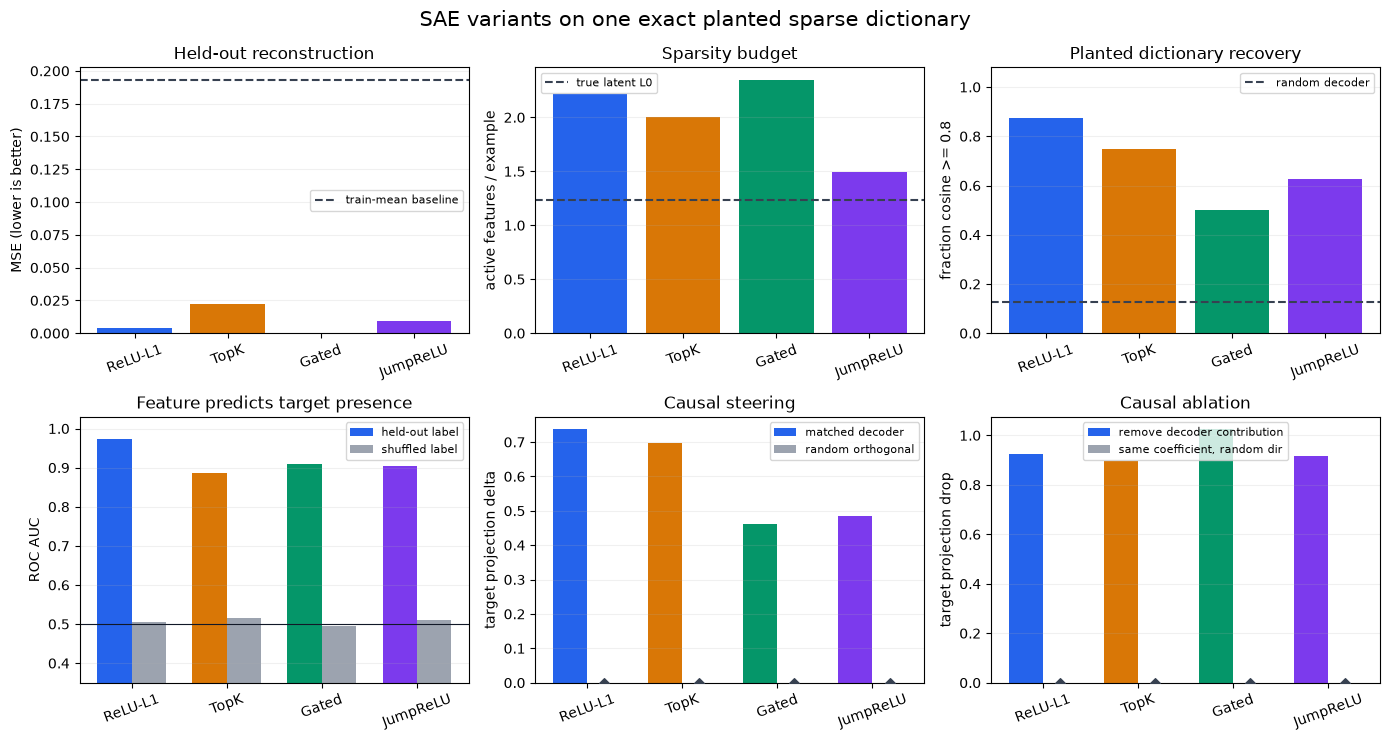

Saved reviewer snapshot to /home/bitwise/Documents/ARENA_3.0_Extended/chapter6_sparse_feature_methods/instructions/assets/sae_variants_signature_result.png


In [9]:
comparison = run_student_comparison()
metric_rows = reference.comparison_rows(comparison)
metric_table = pd.DataFrame(metric_rows).round(4)
display(metric_table)

signature_path = asset_dir / "sae_variants_signature_result.png"
figure = reference.plot_signature_result(comparison, save_path=signature_path)
plt.show()
print(f"Saved reviewer snapshot to {signature_path}")


## Interpreting the Result

<details>
<summary>Why can gated win reconstruction and lose recovery?</summary>

Reconstruction only asks whether the learned features span the activation cloud. Several decoder rows can combine to reconstruct well while duplicating or rotating away from the planted causes. The exact dictionary exposes this. It is a concrete warning against ranking SAEs by reconstruction loss alone.

</details>

<details>
<summary>Does TopK's L0 prove it found the right features?</summary>

No. TopK fixes an activation budget by construction. It controls how many coordinates fire, but dictionary recovery and held-out AUC decide whether those coordinates align with the planted causes. The small gap below exactly `2.0` comes from rows where one selected nonnegative value is zero.

</details>

<details>
<summary>What does the causal panel establish?</summary>

It establishes that the matched learned decoder direction can move, and its decoded contribution can reduce, a known planted projection. The equal-strength orthogonal direction does not. This is a causal result for the planted score; it is not evidence about text generation or a language-model concept.

</details>


## Try It Yourself

Change one variable at a time. A useful first sweep changes the sparsity budget while keeping the dataset fixed.


In [10]:
# Try It Yourself: uncomment one setting, rerun, and compare all six panels.
# play = run_student_comparison(sparsity_coefficient=0.005, seed=1)
# play = run_student_comparison(sparsity_coefficient=0.05, seed=1)
# play = run_student_comparison(k=1, seed=1)
# play = run_student_comparison(k=4, seed=1)
# display(pd.DataFrame(reference.comparison_rows(play)).round(4))
# reference.plot_signature_result(play)
# plt.show()


## Anomaly Hunting

Find one run where a tempting single metric gives the wrong conclusion. Good targets:

- Increase `noise_std` until held-out AUC degrades before reconstruction does.
- Increase `sparsity_coefficient` until recovery improves and then collapses through dead features.
- Set `n_features=12` with `d_model=6` and look for duplicate learned rows.
- Repeat seeds `1, 2, 3, 4`; report whether the variant ranking is stable.
- Correlate two planted supports and test whether one learned feature absorbs both.

Record the seed and all changed parameters. A negative result is useful when it identifies which claim failed.


## Optional Real Pythia Path

The section-local `reference.run_gpu_test(max_vram_gb=24.0)` is an actual experiment path. It loads `EleutherAI/pythia-70m-deduped` at revision `e93a9faa9c77e5d09219f6c868bfc7a1bd65593c`, extracts final-token hidden states from 64 generated train prompts and 16 topic-disjoint held-out prompts, normalizes using train statistics, and trains a width-256 TopK-16 SAE for 800 steps. It measures held-out reconstruction against zero and permuted-decoder controls, freezes feature selection on train labels before held-out AUC, and checks decoder-direction and vocabulary-logit effects. The pinned run deliberately records the train-selected feature's held-out failure as a negative result; it does not turn training-set separation into a semantic-feature claim.

The parent runner owns CUDA execution. The CPU notebook does not load `verification_report.json` as its result and does not substitute synthetic values for this path. A refreshed report remains supporting evidence only.

```bash
.venv/bin/python -c "from chapter6_sparse_feature_methods.exercises.part1_sae_variants.solutions import run_gpu_test; print(run_gpu_test())"
```


In [11]:
real_model_config = {
    "model": reference.PYTHIA_SAE_MODEL_ID,
    "revision": reference.PYTHIA_SAE_REVISION,
    "hidden_layer": reference.PYTHIA_SAE_HIDDEN_LAYER,
    "train_prompts": 64,
    "heldout_prompts": 16,
    "sae_width": reference.PYTHIA_SAE_WIDTH,
    "topk": reference.PYTHIA_SAE_TOPK,
    "training_steps": reference.PYTHIA_SAE_TRAINING_STEPS,
    "executed_in_this_cpu_notebook": False,
}
display(pd.DataFrame([real_model_config]).T.rename(columns={0: "value"}))


,value
model,EleutherAI/pythia-70m-deduped
revision,e93a9faa9c77e5d09219f6c868bfc7a1bd65593c
hidden_layer,-1
train_prompts,64
heldout_prompts,16
sae_width,256
topk,16
training_steps,800
executed_in_this_cpu_notebook,False


In [12]:
def run_gpu_test(max_vram_gb: float = 24.0):
    """Parent-owned optional CUDA path; never called by the CPU lesson."""
    return reference.run_gpu_test(max_vram_gb=max_vram_gb)


def run_full_experiment(max_vram_gb: float = 24.0):
    return run_gpu_test(max_vram_gb=max_vram_gb)


## Limitations

- The planted score is a known linear projection, not a language-model behavior.
- One dictionary, one sparsity level, and one optimization budget cannot establish a global variant ranking.
- The four sparsity coefficients are not perfectly comparable: TopK fixes L0 directly, while the other objectives trade units of reconstruction against different penalties.
- Decoder cosine above `0.8` is a transparent recovery criterion, not a universal interpretability threshold.
- Feature zero is chosen before training; the AUC exercise validates recovery of that known cause and does not automate semantic labeling.
- The Pythia path is a small final-token preflight. It does not establish clean semantic features, full-scale SAE quality, or generated-text steering.

## Reading

- [Toy Models of Superposition](https://transformer-circuits.pub/2022/toy_model/index.html)
- [Improving Dictionary Learning with Gated Sparse Autoencoders](https://arxiv.org/abs/2404.16014)
- [Scaling and evaluating sparse autoencoders](https://arxiv.org/abs/2406.04093)
- [Jumping Ahead: Improving Reconstruction Fidelity with JumpReLU Sparse Autoencoders](https://arxiv.org/abs/2407.14435)
- [Pythia: A Suite for Analyzing Large Language Models Across Training and Scaling](https://arxiv.org/abs/2304.01373)


In [13]:
def run_smoke_test(cpu: bool = True) -> dict:
    assert cpu, "the learner smoke test is CPU-only"
    smoke = run_student_comparison(steps=250, train_examples=1024, heldout_examples=512)
    return {
        "variants": reference.comparison_rows(smoke),
        "zero_baseline_mse": smoke.zero_baseline_mse,
        "true_l0": smoke.true_l0,
    }


tests.test_notebook_contract(run_smoke_test)


All tests in `test_notebook_contract` passed!
